# Group Project — Data Engineering & EDA Pipeline
### Dataset: AI Adoption in Companies (`ai_company_adoption.csv`, from `archive.zip`)

This notebook follows the same **ETL/EDA structure** used in the Week 2–3 Arrhythmia lab (Lab 2/3),
adapted to our approved group-project dataset. Where the lab used demographic/ECG variables to predict
`arrhythmia_present`, this notebook uses company/AI-adoption variables to explore `ai_adoption_stage`
and a derived binary flag `high_adoption`.

**Dataset structure (documented for Phase 1 Task 2):** 150,000 rows = quarterly survey responses from
10,000 companies (~16 quarters each, 2023–2026), 43 columns covering firmographics (industry, size,
region, revenue, employees), AI-adoption metrics (adoption rate/stage, maturity score, budget %,
tools used), and outcome metrics (productivity, jobs displaced/created, satisfaction).

> Assumptions used below (adjust if your group's approved framing differs):
> - Main analysis dataset = `ai_company_adoption.csv`. `ai_industry_summary.csv` and
>   `country_ai_index.csv` are treated as optional lookup/reference tables (not merged in yet).
> - Target variable mirrors the lab's `arrhythmia_present`: a binary `high_adoption` flag
>   (`True` when `ai_adoption_stage` is `"partial"` or `"full"`), alongside the original
>   4-level `ai_adoption_stage` for multiclass exploration (analogous to `class`/`class_names`).

In [1]:
import pandas as pd
import zipfile
import os

# Load the approved dataset (extract from archive.zip if the CSV isn't already alongside this notebook)
CSV_NAME = "ai_company_adoption.csv"
ZIP_NAME = "archive.zip"

if not os.path.exists(CSV_NAME) and os.path.exists(ZIP_NAME):
    with zipfile.ZipFile(ZIP_NAME) as z:
        z.extractall(".")

df = pd.read_csv(CSV_NAME)

print("Raw shape:", df.shape)
print(df.head())

Raw shape: (150000, 43)
   response_id  company_id  survey_year quarter country  region   industry  \
0            1  COMP-00001         2023      Q1   Italy  Europe  Education   
1            2  COMP-00001         2023      Q2   Italy  Europe  Education   
2            3  COMP-00001         2023      Q3   Italy  Europe  Education   
3            4  COMP-00001         2023      Q4   Italy  Europe  Education   
4            5  COMP-00001         2024      Q1   Italy  Europe  Education   

  company_size  num_employees  annual_revenue_usd_millions  ...  \
0      Startup             57                        48.31  ...   
1      Startup             57                        48.31  ...   
2      Startup             57                        48.31  ...   
3      Startup             57                        48.31  ...   
4      Startup             57                        48.31  ...   

   productivity_change_percent  jobs_displaced jobs_created  \
0                         2.65           

## Step 3 (adapted) — Load and type the dataset
Unlike the Arrhythmia file, `ai_company_adoption.csv` already has a header row, so no manual column
naming is needed. Instead, we convert the free-text categorical columns to pandas `category` dtype —
this is the equivalent data-engineering step (correct data types before analysis).

In [2]:
categorical_cols = [
    "country", "region", "industry", "company_size", "quarter",
    "ai_adoption_stage", "ai_primary_tool", "ai_use_case",
    "company_age_group", "data_privacy_level", "ai_ethics_committee",
    "survey_source", "data_collection_method",
]
for col in categorical_cols:
    df[col] = df[col].astype("category")

print(df.dtypes.value_counts())

float64     15
int64       14
str          1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


## Step 4 (adapted) — Protect the raw data and describe structure
Same pattern as the lab: keep an untouched `df_original`, and never edit it directly. All cleaning
happens on copies via a `clean_data()` function, mirroring the lab's approach.

In [3]:
df_original = df.copy(deep=True)

print("Records:", df_original.shape[0])
print("Columns:", df_original.shape[1])
print("\nData-type counts:")
print(df_original.dtypes.value_counts())

df_original.info()

print("\nSummary of numeric columns:")
print(df_original.describe())

Records: 150000
Columns: 43

Data-type counts:
float64     15
int64       14
str          1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   response_id                  150000 non-null  int64   
 1   company_id                   150000 non-null  str     
 2   survey_year                  150000 non-null  int64   
 3   quarter                      150000 non-null  category
 4   country                      150000 non-null  category
 5   region                       150000 non-null  category
 6   industry                     150000 non-null  category
 7   company_size                 150000 non-nu

         response_id    survey_year  num_employees  \
count  150000.000000  150000.000000  150000.000000   
mean    79961.106207    2024.500987    2342.376580   
std     46158.813039       1.118013    4754.424755   
min         1.000000    2023.000000      10.000000   
25%     40020.750000    2024.000000      69.000000   
50%     79937.500000    2025.000000     349.000000   
75%    119913.250000    2026.000000     884.000000   
max    160000.000000    2026.000000   19970.000000   

       annual_revenue_usd_millions  company_founding_year    company_age  \
count                150000.000000          150000.000000  150000.000000   
mean                   1180.345751            2005.993767      18.507220   
std                    2391.471420               9.473220       9.539367   
min                       1.010000            1990.000000       1.000000   
25%                      33.880000            1998.000000      10.000000   
50%                     184.160000            2006.000000

## Step 5 (adapted) — Inspect data quality before cleaning
Check missingness, duplicates, ranges, and the target distribution — same checks as the lab, run
against our dataset's columns instead of ECG/demographic columns.

In [4]:
# Missing values
missing = df_original.isna().sum()
print("Columns containing missing values:")
print(missing[missing > 0].sort_values(ascending=False))

# Duplicate rows / duplicate response IDs
print("\nNumber of fully duplicate rows:", df_original.duplicated().sum())
print("Number of duplicate response_id values:", df_original["response_id"].duplicated().sum())

# Important ranges
range_cols = ["num_employees", "annual_revenue_usd_millions", "ai_adoption_rate", "ai_maturity_score"]
print("\nMinimum and maximum values:")
print(df_original[range_cols].agg(["min", "max"]))

# Target distribution
print("\nRecords per adoption stage:")
print(df_original["ai_adoption_stage"].value_counts())

Columns containing missing values:
Series([], dtype: int64)



Number of fully duplicate rows: 0
Number of duplicate response_id values: 0

Minimum and maximum values:


     num_employees  annual_revenue_usd_millions  ai_adoption_rate  \
min             10                         1.01               0.0   
max          19970                      9996.73             100.0   

     ai_maturity_score  
min              0.000  
max              0.904  

Records per adoption stage:
ai_adoption_stage
partial    78800
pilot      64317
none        5198
full        1685
Name: count, dtype: int64


Same pattern as the lab's `review_cols` check on age/height/weight: review records for
**logically** inconsistent combinations before deciding whether anything needs to be removed
(don't clean just because a value looks unusual).

In [5]:
review_cols = ["company_id", "company_age", "years_using_ai", "ai_adoption_rate", "ai_adoption_stage"]

records_to_review = df_original.loc[
    (df_original["years_using_ai"] > df_original["company_age"])
    | (df_original["num_employees"] <= 0)
    | (df_original["annual_revenue_usd_millions"] <= 0),
    review_cols
]
print("Logically inconsistent records found:", len(records_to_review))
print(records_to_review.to_string())

# Spot-check: does annual_revenue x ai_budget_percentage / num_employees line up with the
# reported ai_investment_per_employee? (consistency check, not a "wrong value" check)
calc_investment = (
    df_original["annual_revenue_usd_millions"] * 1e6
    * df_original["ai_budget_percentage"] / 100
    / df_original["num_employees"]
)
mismatch = (calc_investment - df_original["ai_investment_per_employee"]).abs() > 1.0
print("\nRows where recomputed investment/employee differs from the reported value by >$1:",
      mismatch.sum(), "of", len(df_original))

Logically inconsistent records found: 0
Empty DataFrame
Columns: [company_id, company_age, years_using_ai, ai_adoption_rate, ai_adoption_stage]
Index: []

Rows where recomputed investment/employee differs from the reported value by >$1: 139098 of 150000


## Step 6 (adapted) — Define, apply and verify the cleaning function
Same shape as the lab's `clean_data()`: work on a deep copy, remove records that are logically
invalid (none turned up in this dataset — worth stating explicitly in the report), engineer a
derived feature (`revenue_per_employee`, the equivalent of the lab's `bmi`), impute any missing
values defensively, drop an uninformative identifier column, deduplicate, and add the binary
target.

In [6]:
def clean_data(data):
    clean = data.copy(deep=True)

    # Engineered feature (equivalent role to "bmi" in the lab)
    clean["revenue_per_employee"] = (
        clean["annual_revenue_usd_millions"] * 1e6 / clean["num_employees"]
    )

    invalid_record = (
        (clean["years_using_ai"] > clean["company_age"])
        | (clean["num_employees"] <= 0)
        | (clean["annual_revenue_usd_millions"] <= 0)
    )
    print("Clearly invalid records removed:")
    print(clean.loc[invalid_record, review_cols])

    clean = clean.loc[~invalid_record].copy()

    # Defensive median-fill (no missing values currently, but keeps the pipeline robust
    # if a future extract/export introduces gaps)
    for col in ["ai_maturity_score", "employee_satisfaction_score", "customer_satisfaction"]:
        clean[col] = clean[col].fillna(clean[col].median())

    # response_id is a row index with no analytical value
    clean = clean.drop(columns=["response_id"], errors="ignore")
    clean = clean.drop_duplicates()

    # Binary target, equivalent to the lab's "arrhythmia_present"
    clean["high_adoption"] = clean["ai_adoption_stage"].isin(["partial", "full"])

    clean = clean.reset_index(drop=True)
    return clean

In [7]:
df_etl_clean = clean_data(df_original)

print("Original shape:", df_original.shape)
print("Cleaned shape:", df_etl_clean.shape)
print("Rows removed:", len(df_original) - len(df_etl_clean))

print("\nresponse_id still present:", "response_id" in df_etl_clean.columns)
print("Duplicate rows:", df_etl_clean.duplicated().sum())
print("revenue_per_employee added:", "revenue_per_employee" in df_etl_clean.columns)

Clearly invalid records removed:
Empty DataFrame
Columns: [company_id, company_age, years_using_ai, ai_adoption_rate, ai_adoption_stage]
Index: []


Original shape: (150000, 43)
Cleaned shape: (150000, 44)
Rows removed: 0

response_id still present: False
Duplicate rows: 0
revenue_per_employee added: True


## Step 7 — Demonstrate ETL and ELT
Identical pattern to the lab, just against our dataset/tables.

In [8]:
import sqlite3

# ETL: transform first, then load
with sqlite3.connect("etl.db") as conn:
    df_etl_clean.to_sql("clean", conn, if_exists="replace", index=False)

# ELT: load raw first, then transform
with sqlite3.connect("elt.db") as conn:
    df_original.to_sql("raw", conn, if_exists="replace", index=False)

    df_elt_raw = pd.read_sql("SELECT * FROM raw", conn)
    df_elt_clean = clean_data(df_elt_raw)
    df_elt_clean.to_sql("clean", conn, if_exists="replace", index=False)

print("ETL clean shape:", df_etl_clean.shape)
print("ELT raw shape:", df_elt_raw.shape)
print("ELT clean shape:", df_elt_clean.shape)

Clearly invalid records removed:
Empty DataFrame
Columns: [company_id, company_age, years_using_ai, ai_adoption_rate, ai_adoption_stage]
Index: []


ETL clean shape: (150000, 44)
ELT raw shape: (150000, 43)
ELT clean shape: (150000, 44)


In [9]:
with sqlite3.connect("etl.db") as conn:
    print("Tables in etl.db:")
    print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn))

with sqlite3.connect("elt.db") as conn:
    print("\nTables in elt.db:")
    print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn))

Tables in etl.db:
    name
0  clean

Tables in elt.db:
    name
0    raw
1  clean


## Part A — Series vs DataFrame, and loop vs vectorised execution
Same demonstration as the lab, using `revenue_per_employee` (annual revenue × 1e6 / employees)
in place of `weight / height`.

In [10]:
# Series versus DataFrame
print(df_original["ai_adoption_rate"].mean())
print(df_original[["ai_adoption_rate", "ai_maturity_score"]].mean())

import time
# Slow method: loop
start = time.time()
slow_result = []
for i in range(len(df_original)):
    slow_result.append(
        df_original["annual_revenue_usd_millions"].iloc[i] * 1e6
        / df_original["num_employees"].iloc[i]
    )
slow_time = time.time() - start

# Fast method: vectorised calculation
start = time.time()
fast_result = df_original["annual_revenue_usd_millions"] * 1e6 / df_original["num_employees"]
fast_time = time.time() - start

print("Slow result:", slow_result[:5])
print("Fast result:", fast_result.head().tolist())
print("\nSlow time:", slow_time)
print("Fast time:", fast_time)
print("Fast method is", slow_time / fast_time, "times faster")

print(df_original.shape)
print(df_original.dtypes.value_counts())
df_original.info()

36.41472566666666
ai_adoption_rate     36.414726
ai_maturity_score     0.344675
dtype: float64


Slow result: [np.float64(847543.8596491228), np.float64(847543.8596491228), np.float64(847543.8596491228), np.float64(847543.8596491228), np.float64(847543.8596491228)]
Fast result: [847543.8596491228, 847543.8596491228, 847543.8596491228, 847543.8596491228, 847543.8596491228]

Slow time: 6.89296555519104
Fast time: 0.0017538070678710938
Fast method is 3930.287248504622 times faster
(150000, 43)
float64     15
int64       14
str          1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   response_id                  150000 non-null  int64   
 1   company_id                   150000 non-null  str 

## Part B — Exploration
### 8.1 Descriptive statistics and target distribution

In [11]:
summary_cols = ["ai_adoption_rate", "ai_maturity_score", "employee_satisfaction_score", "productivity_change_percent"]

print(df_etl_clean[summary_cols].describe())

skew_results = df_etl_clean[summary_cols].skew().round(2)
print(skew_results)

print(df_etl_clean["high_adoption"].value_counts(normalize=True))

print("Minimum adoption rate retained:", df_etl_clean["ai_adoption_rate"].min())
print("Minimum employees retained:", df_etl_clean["num_employees"].min())

       ai_adoption_rate  ai_maturity_score  employee_satisfaction_score  \
count     150000.000000      150000.000000                150000.000000   
mean          36.414726           0.344675                     5.600767   
std           14.544096           0.133820                     0.814567   
min            0.000000           0.000000                     2.100000   
25%           26.430000           0.250000                     5.050000   
50%           36.320000           0.341000                     5.600000   
75%           46.200000           0.435000                     6.150000   
max          100.000000           0.904000                     9.200000   

       productivity_change_percent  
count                150000.000000  
mean                      9.266996  
std                       5.637067  
min                       0.000000  
25%                       5.070000  
50%                       9.060000  
75%                      13.120000  
max                      34.

### 8.2 Histograms before and after cleaning

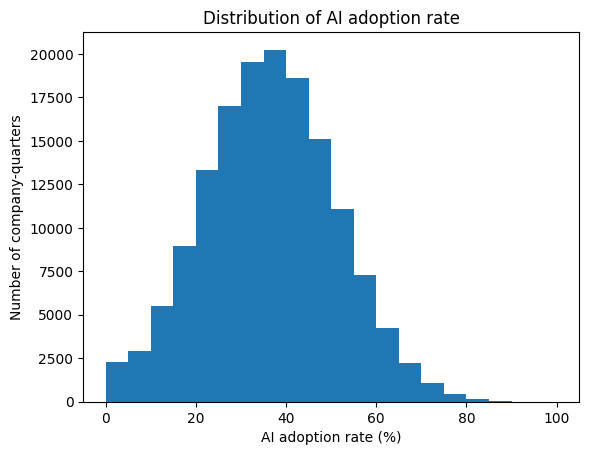

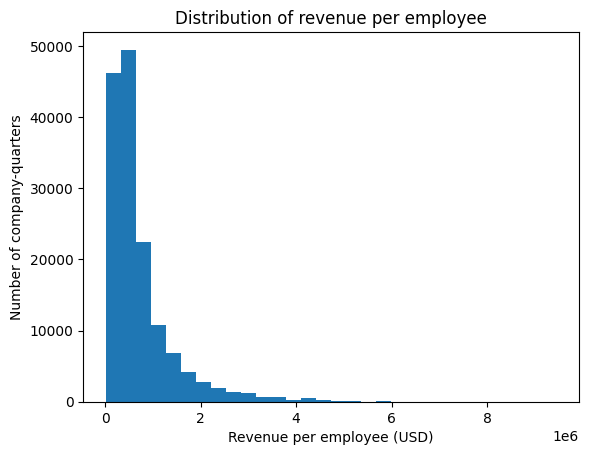

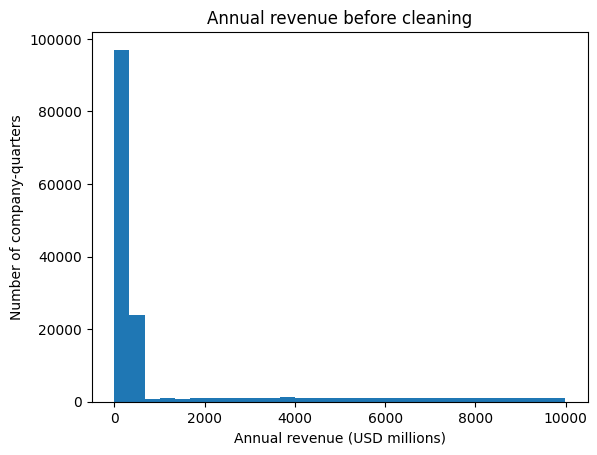

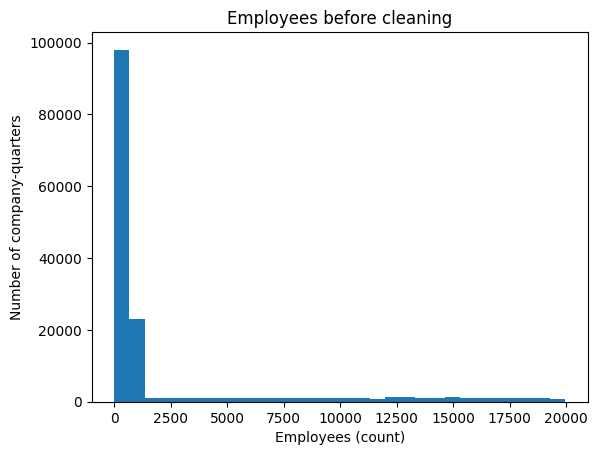

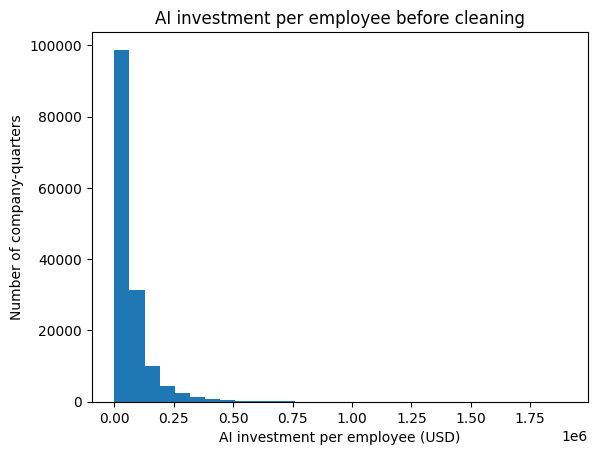

num_employees raw range: (np.int64(10), np.int64(19970)) clean range: (np.int64(10), np.int64(19970))
annual_revenue_usd_millions raw range: (np.float64(1.01), np.float64(9996.73)) clean range: (np.float64(1.01), np.float64(9996.73))
ai_adoption_rate raw range: (np.float64(0.0), np.float64(100.0)) clean range: (np.float64(0.0), np.float64(100.0))


In [12]:
import matplotlib.pyplot as plt

# Cleaned-data distributions
plt.hist(df_etl_clean["ai_adoption_rate"].dropna(), bins=20)
plt.xlabel("AI adoption rate (%)")
plt.ylabel("Number of company-quarters")
plt.title("Distribution of AI adoption rate")
plt.show()

plt.hist(df_etl_clean["revenue_per_employee"].dropna(), bins=30)
plt.xlabel("Revenue per employee (USD)")
plt.ylabel("Number of company-quarters")
plt.title("Distribution of revenue per employee")
plt.show()

# Raw distributions, before cleaning
for col, label, unit in [
    ("annual_revenue_usd_millions", "Annual revenue", "USD millions"),
    ("num_employees", "Employees", "count"),
    ("ai_investment_per_employee", "AI investment per employee", "USD"),
]:
    plt.hist(df_original[col].dropna(), bins=30)
    plt.title(f"{label} before cleaning")
    plt.xlabel(f"{label} ({unit})")
    plt.ylabel("Number of company-quarters")
    plt.show()

# Compare raw and cleaned ranges
for col in ["num_employees", "annual_revenue_usd_millions", "ai_adoption_rate"]:
    print(
        col,
        "raw range:", (df_original[col].min(), df_original[col].max()),
        "clean range:", (df_etl_clean[col].min(), df_etl_clean[col].max()),
    )

### 8.3 Outlier investigation — boxplot, IQR flags, and z-score check

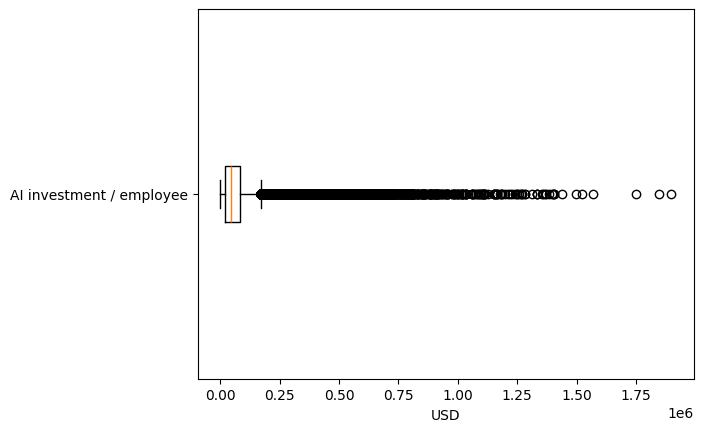

Rows flagged by IQR on revenue/employees/AI-investment: 37394 of 150000

AI-investment-per-employee values with |z| > 3: 3063


In [13]:
# Boxplot for a heavily right-skewed variable
plt.boxplot(df_etl_clean["ai_investment_per_employee"].dropna(), vert=False, labels=["AI investment / employee"])
plt.xlabel("USD")
plt.show()

def iqr_flag(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

revenue_flag = iqr_flag(df_etl_clean["annual_revenue_usd_millions"])
employee_flag = iqr_flag(df_etl_clean["num_employees"])
investment_flag = iqr_flag(df_etl_clean["ai_investment_per_employee"])

firmographic_flags = revenue_flag | employee_flag | investment_flag
print("Rows flagged by IQR on revenue/employees/AI-investment:", firmographic_flags.sum(),
      "of", len(df_etl_clean))

# AI investment per employee checked separately with a z-score
mean_inv = df_etl_clean["ai_investment_per_employee"].mean()
std_inv = df_etl_clean["ai_investment_per_employee"].std()
z_inv = (df_etl_clean["ai_investment_per_employee"] - mean_inv) / std_inv

print("\nAI-investment-per-employee values with |z| > 3:", (z_inv.abs() > 3).sum())

### 8.4 Optional sensitivity view (capped copy, does not alter `df_etl_clean`)
Same pattern as the lab's sensitivity check: cap a *copy* of the skewed columns at the IQR fences
to see how much the picture changes, without touching the main cleaned dataframe.

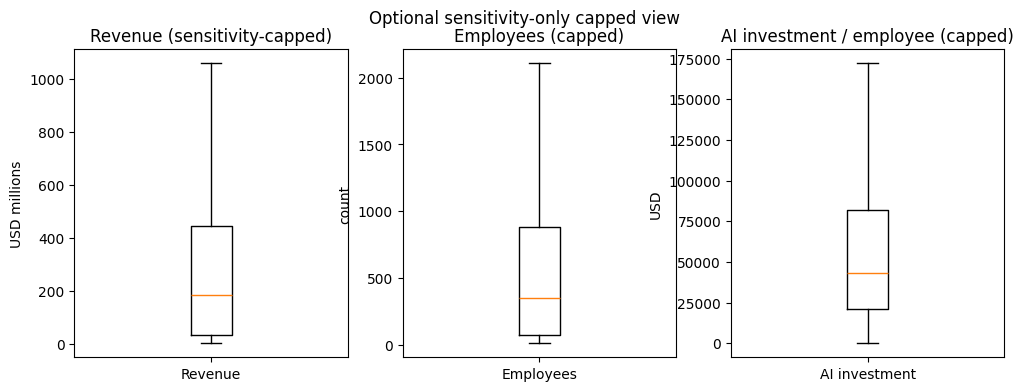

In [14]:
df_sensitivity = df_etl_clean.copy(deep=True)

for col in ["annual_revenue_usd_millions", "num_employees", "ai_investment_per_employee"]:
    q1, q3 = df_sensitivity[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df_sensitivity[col + "_capped"] = df_sensitivity[col].clip(lower, upper)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].boxplot(df_sensitivity["annual_revenue_usd_millions_capped"].dropna(), labels=["Revenue"])
axes[0].set_title("Revenue (sensitivity-capped)")
axes[0].set_ylabel("USD millions")

axes[1].boxplot(df_sensitivity["num_employees_capped"].dropna(), labels=["Employees"])
axes[1].set_title("Employees (capped)")
axes[1].set_ylabel("count")

axes[2].boxplot(df_sensitivity["ai_investment_per_employee_capped"].dropna(), labels=["AI investment"])
axes[2].set_title("AI investment / employee (capped)")
axes[2].set_ylabel("USD")

plt.suptitle("Optional sensitivity-only capped view")
plt.show()

In [15]:
print("df_etl_clean columns unchanged:",
      "annual_revenue_usd_millions_capped" not in df_etl_clean.columns)
print(df_etl_clean.shape)

df_etl_clean columns unchanged: True
(150000, 44)


### 8.5 Group comparisons and correlation heatmap
Equivalent of the lab's "arrhythmia rate by sex" bar chart and correlation heatmap.

company_size
SME           0.493635
Startup       0.495987
Enterprise    0.707790
Name: high_adoption, dtype: float64


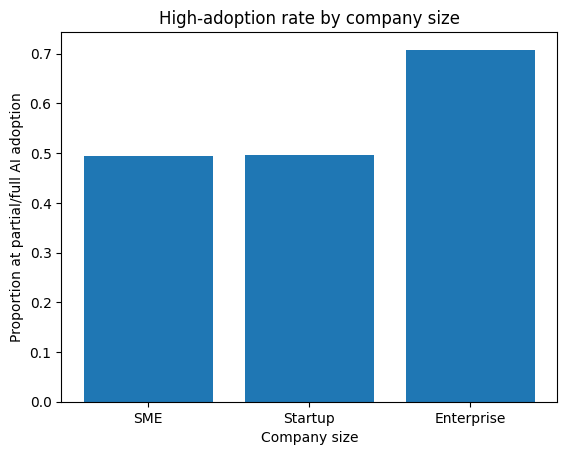

                             ai_adoption_rate  ai_maturity_score  \
ai_adoption_rate                         1.00               0.84   
ai_maturity_score                        0.84               1.00   
ai_training_hours                        0.73               0.82   
ai_budget_percentage                     0.74               0.82   
productivity_change_percent              0.67               0.74   
employee_satisfaction_score              0.33               0.38   
revenue_growth_percent                   0.41               0.40   

                             ai_training_hours  ai_budget_percentage  \
ai_adoption_rate                          0.73                  0.74   
ai_maturity_score                         0.82                  0.82   
ai_training_hours                         1.00                  0.56   
ai_budget_percentage                      0.56                  1.00   
productivity_change_percent               0.63                  0.60   
employee_satisfaction_s

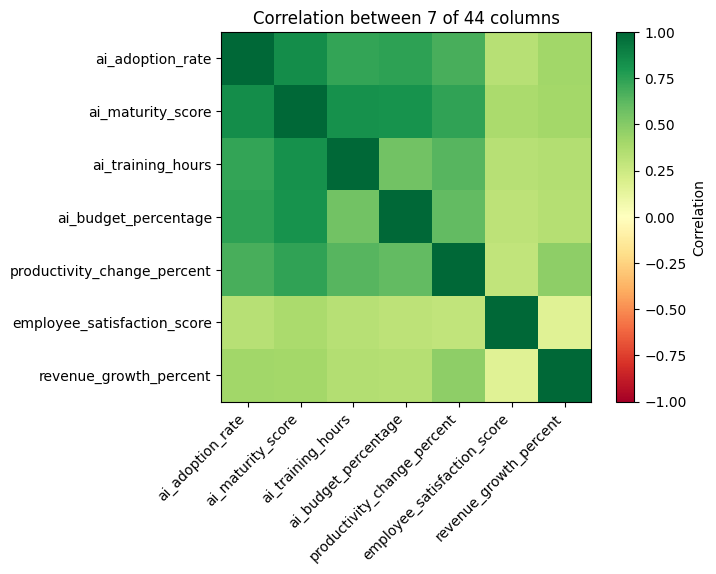

In [16]:
import numpy as np

# High-adoption rate by company size
rate_by_size = (
    df_etl_clean
    .groupby("company_size", observed=True)["high_adoption"]
    .mean()
    .sort_values()
)
print(rate_by_size)

plt.bar(rate_by_size.index.astype(str), rate_by_size.values)
plt.xlabel("Company size")
plt.ylabel("Proportion at partial/full AI adoption")
plt.title("High-adoption rate by company size")
plt.show()

# Correlation heatmap
num_cols = [
    "ai_adoption_rate", "ai_maturity_score", "ai_training_hours",
    "ai_budget_percentage", "productivity_change_percent",
    "employee_satisfaction_score", "revenue_growth_percent",
]

corr_matrix = df_etl_clean[num_cols].corr()
print(corr_matrix.round(2))

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
strongest_pair = upper_triangle.abs().stack().idxmax()

print(
    "Strongest absolute correlation:",
    strongest_pair,
    round(corr_matrix.loc[strongest_pair[0], strongest_pair[1]], 2)
)

plt.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(label="Correlation")
plt.title(f"Correlation between {len(num_cols)} of {df_etl_clean.shape[1]} columns")
plt.show()

### 8.6 Profile by adoption stage, and missingness
Equivalent of the lab's per-diagnosis-class profile heatmap and the missing-value bar chart.

Company-quarters per adoption stage:
ai_adoption_stage
partial    78800
pilot      64317
none        5198
full        1685
Name: count, dtype: int64

Mean profile per adoption stage:
                   ai_maturity_score  ai_training_hours  \
ai_adoption_stage                                         
full                            0.65              52.75   
none                            0.12               7.66   
partial                         0.42              33.95   
pilot                           0.26              19.85   

                   productivity_change_percent  employee_satisfaction_score  \
ai_adoption_stage                                                             
full                                     19.79                         6.29   
none                                      2.39                         5.09   
partial                                  12.03                         5.80   
pilot                                     6.17                     

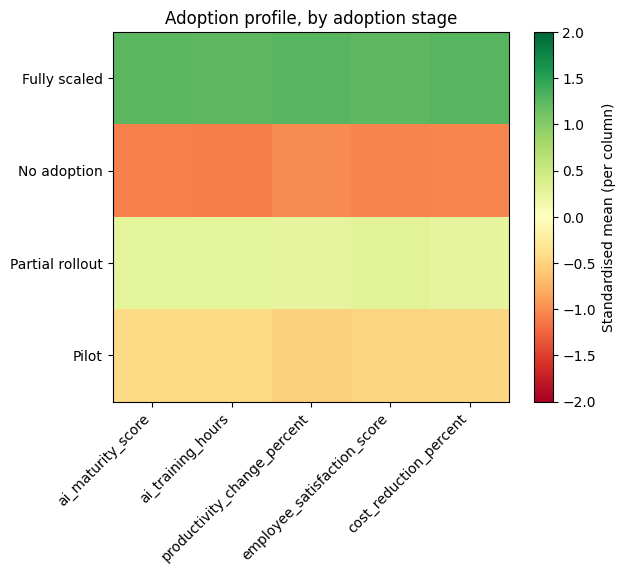


No missing values found in any column of the raw data.


In [17]:
stage_names = {
    "none": "No adoption",
    "pilot": "Pilot",
    "partial": "Partial rollout",
    "full": "Fully scaled",
}

profile_cols = [
    "ai_maturity_score", "ai_training_hours", "productivity_change_percent",
    "employee_satisfaction_score", "cost_reduction_percent",
]

stage_counts = df_etl_clean["ai_adoption_stage"].value_counts()
print("Company-quarters per adoption stage:")
print(stage_counts)

profile = (
    df_etl_clean
    .groupby("ai_adoption_stage", observed=True)[profile_cols]
    .mean()
)
print("\nMean profile per adoption stage:")
print(profile.round(2))

profile_z = (profile - profile.mean()) / profile.std()
row_labels = [stage_names[str(s)] for s in profile_z.index]

plt.imshow(profile_z.values, cmap="RdYlGn", vmin=-2, vmax=2, aspect="auto")
plt.xticks(range(len(profile_cols)), profile_cols, rotation=45, ha="right")
plt.yticks(range(len(profile_z)), row_labels)
plt.colorbar(label="Standardised mean (per column)")
plt.title("Adoption profile, by adoption stage")
plt.show()

# Missingness in the raw data
miss = df_original.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0] * 100

if len(miss) == 0:
    print("\nNo missing values found in any column of the raw data.")
else:
    plt.barh(miss.index.astype(str), miss.values)
    plt.xlabel("% missing")
    plt.title("Missing values in the raw data")
    plt.show()

### 8.7 Scatter and pair plots
150,000 rows is too dense to plot meaningfully as-is, so (as you'd note/justify in the report) we
take a random sample for these visuals only — the underlying stats above still use the full cleaned
dataset.

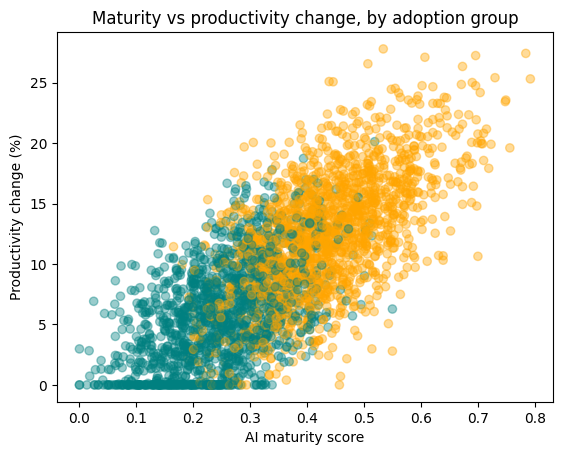

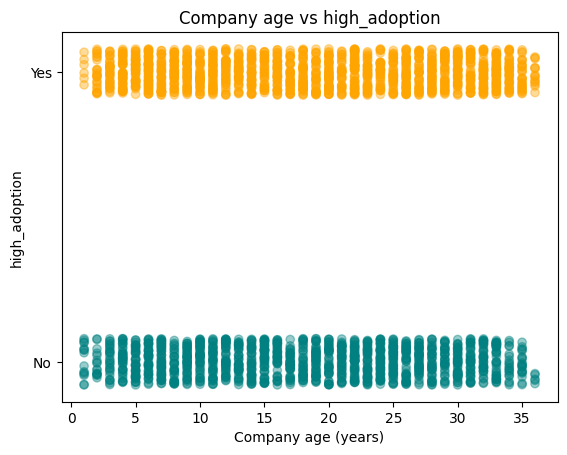

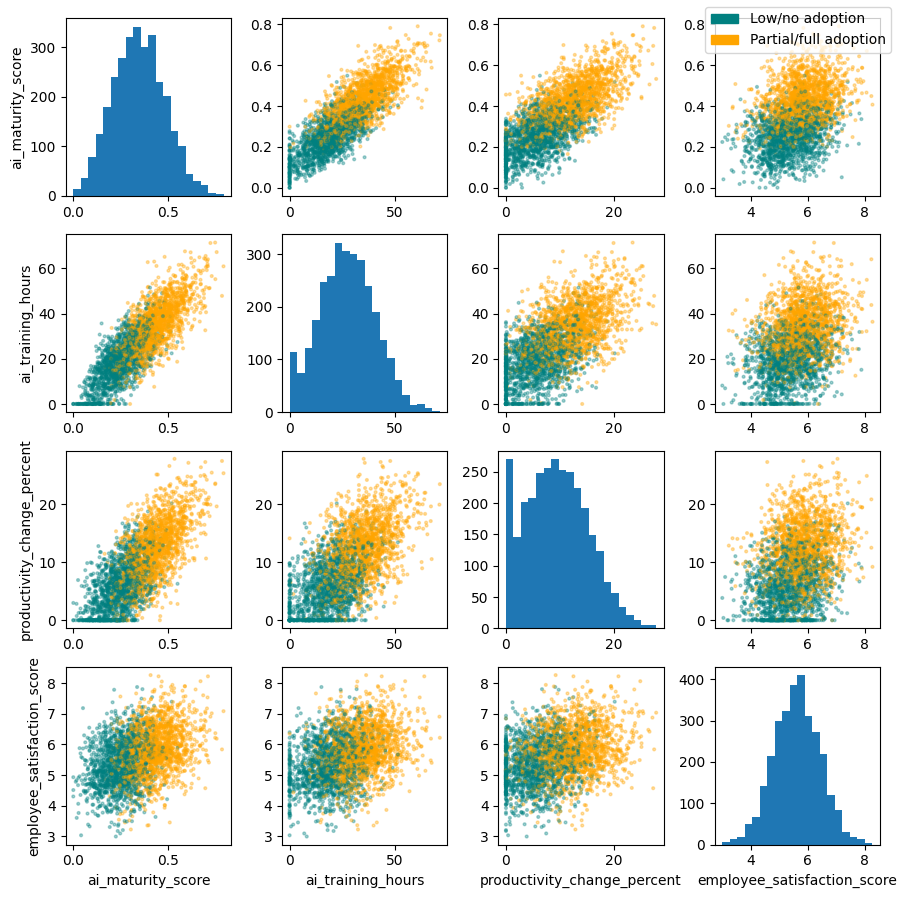

In [18]:
sample = df_etl_clean.sample(n=3000, random_state=42)
colors = sample["high_adoption"].map({True: "orange", False: "teal"})

# Maturity score vs productivity change, by adoption group
plt.scatter(sample["ai_maturity_score"], sample["productivity_change_percent"], c=colors, alpha=0.4)
plt.xlabel("AI maturity score")
plt.ylabel("Productivity change (%)")
plt.title("Maturity vs productivity change, by adoption group")
plt.show()

# Company age versus binary adoption outcome, with jitter
jitter = (
    sample["high_adoption"].astype(int)
    + np.random.uniform(-0.08, 0.08, len(sample))
)

plt.scatter(sample["company_age"], jitter, c=colors, alpha=0.4)
plt.yticks([0, 1], ["No", "Yes"])
plt.xlabel("Company age (years)")
plt.ylabel("high_adoption")
plt.title("Company age vs high_adoption")
plt.show()

# Pair plot constructed with Matplotlib
cols = ["ai_maturity_score", "ai_training_hours", "productivity_change_percent", "employee_satisfaction_score"]
fig, axes = plt.subplots(4, 4, figsize=(9, 9))

for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        ax = axes[i, j]
        if i == j:
            ax.hist(sample[c1].dropna(), bins=20)
        else:
            ax.scatter(sample[c2], sample[c1], s=4, alpha=0.35, c=colors)
        if i == 3:
            ax.set_xlabel(c2)
        if j == 0:
            ax.set_ylabel(c1)

plt.tight_layout()

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(color="teal", label="Low/no adoption"),
    Patch(color="orange", label="Partial/full adoption"),
], loc="upper right")
plt.show()

### 8.8 Statistical hypothesis tests
Equivalent of the lab's t-test (heart rate by arrhythmia) and chi-square test (sex by diagnosis).

In [19]:
print("Sample mean adoption rate:", df_etl_clean["ai_adoption_rate"].mean())

Sample mean adoption rate: 36.41472566666666


In [20]:
from scipy import stats

a = df_etl_clean.loc[df_etl_clean["high_adoption"], "ai_maturity_score"]
b = df_etl_clean.loc[~df_etl_clean["high_adoption"], "ai_maturity_score"]

t, p = stats.ttest_ind(a, b, equal_var=False)

print("Mean maturity score (high adoption):", a.mean())
print("Mean maturity score (low/no adoption):", b.mean())
print(f"t = {t:.2f}, p = {p:.4f}")

if p < 0.05:
    print("Reject H0: mean AI-maturity scores differ significantly between adoption groups.")
else:
    print("Fail to reject H0: no significant mean difference was detected.")

Mean maturity score (high adoption): 0.42855542026464555
Mean maturity score (low/no adoption): 0.24755662806588508
t = 356.96, p = 0.0000
Reject H0: mean AI-maturity scores differ significantly between adoption groups.


In [21]:
table = pd.crosstab(df_etl_clean["company_size"], df_etl_clean["high_adoption"])
print(table)

chi2, p, dof, expected = stats.chi2_contingency(table)

print(f"chi2 = {chi2:.2f}, p = {p:.6f}")
print("Degrees of freedom:", dof)
print("Expected counts:")
print(expected)

if p < 0.05:
    print("Reject H0: company size and high_adoption are associated in this sample.")
else:
    print("Fail to reject H0: no significant association was detected.")

high_adoption  False  True 
company_size               
Enterprise      8605  20843
SME            32340  31527
Startup        28570  28115
chi2 = 4320.71, p = 0.000000
Degrees of freedom: 2
Expected counts:
[[13647.1848 15800.8152]
 [29598.0967 34268.9033]
 [26269.7185 30415.2815]]
Reject H0: company size and high_adoption are associated in this sample.
